In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv("dataset_traffic_accident_prediction1.csv")

print(df.head())

  Weather   Road_Type Time_of_Day  Traffic_Density  Speed_Limit  \
0   Rainy   City Road     Morning              1.0        100.0   
1   Clear  Rural Road       Night              NaN        120.0   
2   Rainy     Highway     Evening              1.0         60.0   
3   Clear   City Road   Afternoon              2.0         60.0   
4   Rainy     Highway     Morning              1.0        195.0   

   Number_of_Vehicles  Driver_Alcohol Accident_Severity      Road_Condition  \
0                 5.0             0.0               NaN                 Wet   
1                 3.0             0.0          Moderate                 Wet   
2                 4.0             0.0               Low                 Icy   
3                 3.0             0.0               Low  Under Construction   
4                11.0             0.0               Low                 Dry   

  Vehicle_Type  Driver_Age  Driver_Experience Road_Light_Condition  Accident  
0          Car        51.0               48

In [4]:
print(df.columns)

Index(['Weather', 'Road_Type', 'Time_of_Day', 'Traffic_Density', 'Speed_Limit',
       'Number_of_Vehicles', 'Driver_Alcohol', 'Accident_Severity',
       'Road_Condition', 'Vehicle_Type', 'Driver_Age', 'Driver_Experience',
       'Road_Light_Condition', 'Accident'],
      dtype='str')


In [5]:
df = df.dropna()

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'Weather',
    'Road_Type',
    'Time_of_Day',
    'Road_Condition',
    'Vehicle_Type',
    'Road_Light_Condition',
    'Accident_Severity'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [7]:
X = df.drop(['Accident_Severity'], axis=1)
y = df['Accident_Severity']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [10]:
y_pred = model.predict(X_test)

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5308641975308642

Confusion Matrix:
 [[ 2 10  1]
 [ 1 40  8]
 [ 0 18  1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.15      0.25        13
           1       0.59      0.82      0.68        49
           2       0.10      0.05      0.07        19

    accuracy                           0.53        81
   macro avg       0.45      0.34      0.33        81
weighted avg       0.49      0.53      0.47        81



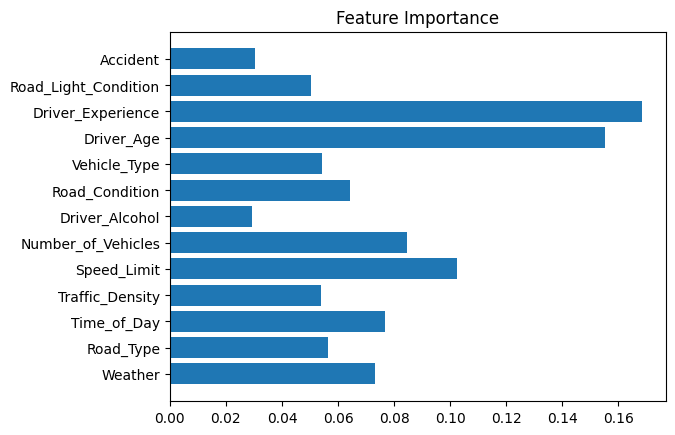

In [12]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

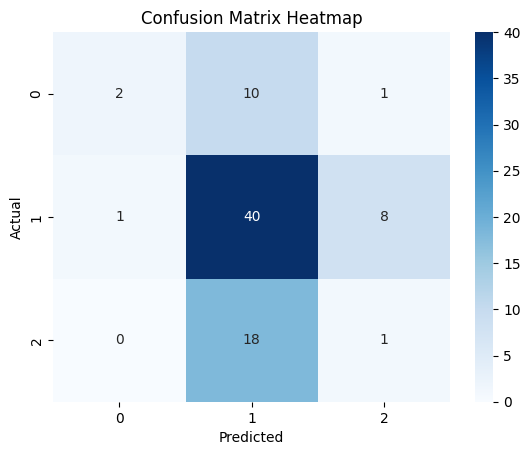

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

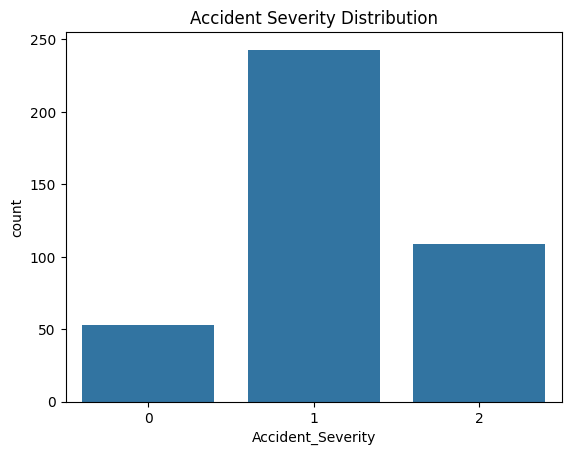

In [14]:
sns.countplot(x='Accident_Severity', data=df)
plt.title("Accident Severity Distribution")
plt.show()

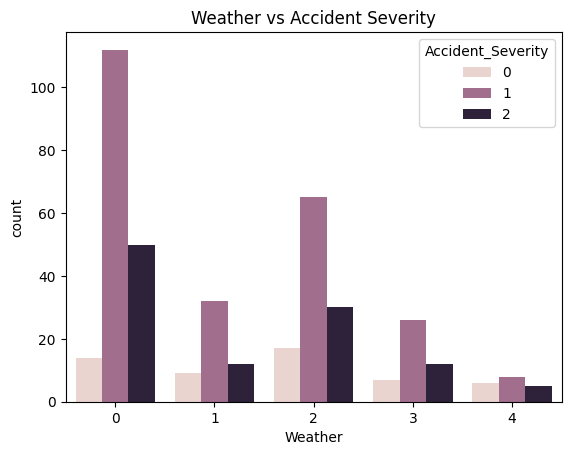

In [15]:
sns.countplot(x='Weather', hue='Accident_Severity', data=df)
plt.title("Weather vs Accident Severity")
plt.show()

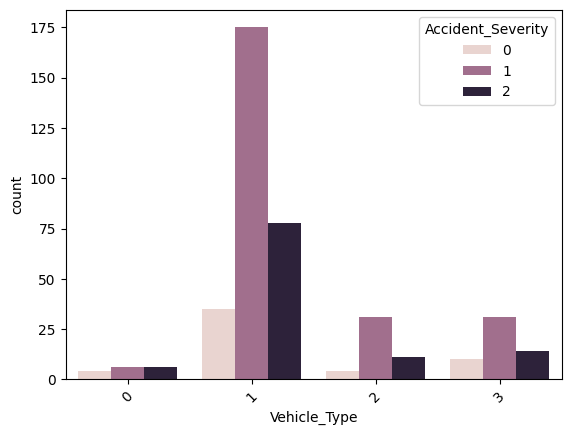

In [16]:
sns.countplot(x='Vehicle_Type', hue='Accident_Severity', data=df)
plt.xticks(rotation=45)
plt.show()

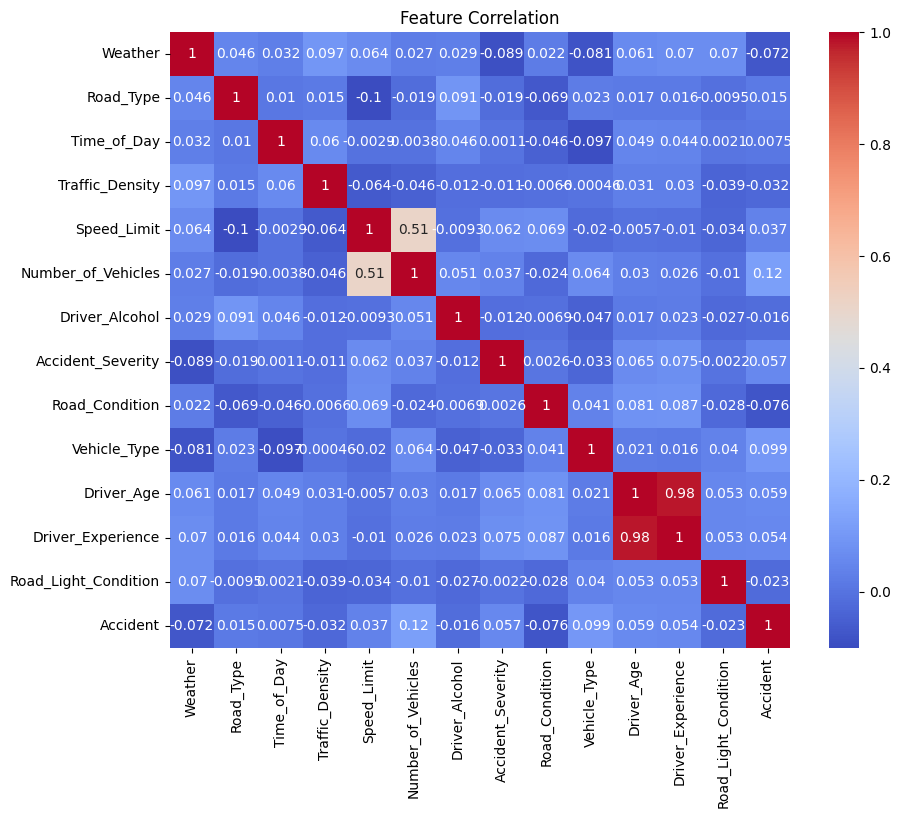

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [18]:
sample = X_test.iloc[0].values.reshape(1, -1)
prediction = model.predict(sample)

print("Predicted Severity:", prediction)

Predicted Severity: [1]


c:\Users\sachd\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [19]:
def risk_alert(pred):
    if pred == 2:  # assume 2 = High
        return "⚠️ HIGH RISK!"
    elif pred == 1:
        return "⚡ Medium Risk"
    else:
        return "✅ Low Risk"

print(risk_alert(prediction[0]))

⚡ Medium Risk


In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, pred))

Random Forest Accuracy: 0.5925925925925926
Decision Tree Accuracy: 0.41975308641975306
KNN Accuracy: 0.5061728395061729


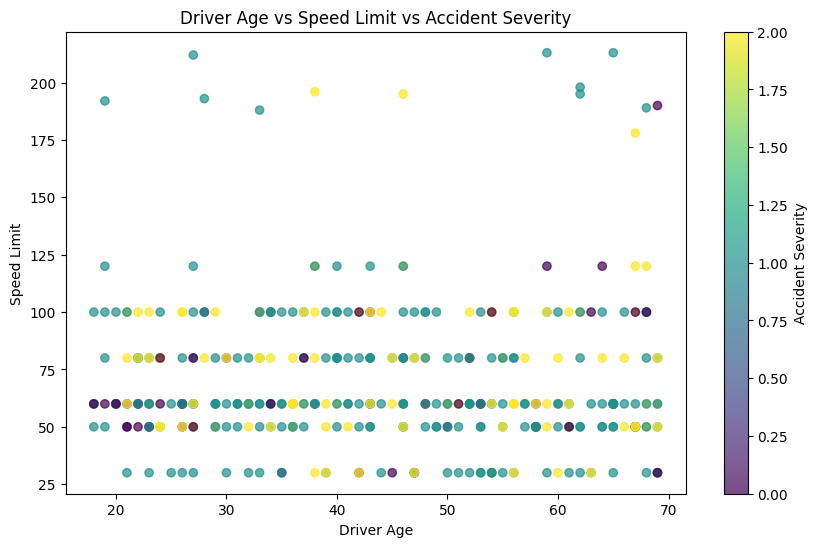

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df['Driver_Age'],
    df['Speed_Limit'],
    c=df['Accident_Severity'],
    cmap='viridis',
    alpha=0.7
)

plt.colorbar(scatter, label='Accident Severity')
plt.xlabel("Driver Age")
plt.ylabel("Speed Limit")
plt.title("Driver Age vs Speed Limit vs Accident Severity")

plt.show()

In [23]:
sample_input = {
    'Weather': 1,
    'Road_Type': 2,
    'Time_of_Day': 1,
    'Traffic_Density': 8,
    'Speed_Limit': 80,
    'Number_of_Vehicles': 15,
    'Driver_Alcohol': 1,
    'Road_Condition': 2,
    'Vehicle_Type': 1,
    'Driver_Age': 22,
    'Driver_Experience': 2,
    'Road_Light_Condition': 1
}

In [24]:
def recommendation(input_data):
    if input_data['Speed_Limit'] > 70:
        return "Reduce Speed 🚗"
    elif input_data['Weather'] == 2:
        return "Drive Carefully in Bad Weather 🌧️"
    else:
        return "Normal Driving Conditions 👍"

print(recommendation(sample_input))

Reduce Speed 🚗
